# Session 2 - Regularized Regression (Ridge & Lasso)

Goal: reuse the Session 1 feature set, preprocessing, target transform, and train/test split, then compare Linear Regression with Ridge and Lasso regularization.

## 1. Key Concepts

- House price prediction is a supervised regression problem because the training data has a known label, `SalePrice`, and the target is a continuous number.
- Supervised learning uses labeled examples; unsupervised learning looks for patterns or groups without a target label.
- Regression predicts numeric values. Classification predicts categories/classes, such as `expensive` vs `not expensive`.

## 2. Ridge And Lasso Notes

- Ridge Regression uses L2 regularization. It adds a penalty that shrinks coefficients toward smaller values, which can reduce overfitting when features are many or correlated.
- Lasso Regression uses L1 regularization. It can shrink some coefficients exactly to zero, so it naturally performs feature selection.
- Larger `alpha` means stronger regularization and a simpler model. Smaller `alpha` behaves more like normal Linear Regression.

In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## 3. Set Up Paths And Import Preprocessing

In [2]:
PROJECT_DIR = Path.cwd()

if PROJECT_DIR.name == "model_training":
    PROJECT_DIR = PROJECT_DIR.parents[1]
elif PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent
elif (PROJECT_DIR / "my-project").exists():
    PROJECT_DIR = PROJECT_DIR / "my-project"

SRC_DIR = PROJECT_DIR / "src"
DATA_PATH = PROJECT_DIR / "data" / "raw" / "train.csv"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
PREPROCESSOR_PATH = ARTIFACTS_DIR / "preprocessor_regularized.pkl"

sys.path.insert(0, str(SRC_DIR))

from ml.preprocessing import preprocess_train

print(f"Project dir: {PROJECT_DIR}")
print(f"Data path: {DATA_PATH}")
print(f"Preprocessor artifact: {PREPROCESSOR_PATH}")

Project dir: c:\Users\ADMIN\OneDrive - The University of Technology\Documents\Intern AgilityIO\internship-hoaihuynh-training\my-project
Data path: c:\Users\ADMIN\OneDrive - The University of Technology\Documents\Intern AgilityIO\internship-hoaihuynh-training\my-project\data\raw\train.csv
Preprocessor artifact: c:\Users\ADMIN\OneDrive - The University of Technology\Documents\Intern AgilityIO\internship-hoaihuynh-training\my-project\artifacts\preprocessor_regularized.pkl


## 4. Load Raw Data And Split Target

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing training data: {DATA_PATH}. "
        "Place Kaggle House Prices train.csv under my-project/data/raw/ first."
    )

df_raw = pd.read_csv(DATA_PATH)

if "SalePrice" not in df_raw.columns:
    raise ValueError("Expected target column `SalePrice` in train.csv")

y_price = df_raw["SalePrice"]
x_raw = df_raw.drop(columns=["SalePrice"])

print(f"Raw feature shape: {x_raw.shape}")
print(f"Target shape: {y_price.shape}")
display(df_raw.head())

Raw feature shape: (1460, 80)
Target shape: (1460,)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 5. Reuse Session 1 Feature Set

In [4]:
num_cols = ["LotFrontage", "MasVnrArea", "TotalBsmtSF"]
cat_cols = ["GarageType", "Alley"]
ord_cols = ["ExterQual"]

selected_cols = num_cols + cat_cols + ord_cols
missing_cols = [col for col in selected_cols if col not in x_raw.columns]

if missing_cols:
    raise ValueError(f"Missing selected columns in train.csv: {missing_cols}")

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)
print("Ordinal columns:", ord_cols)

Numeric columns: ['LotFrontage', 'MasVnrArea', 'TotalBsmtSF']
Categorical columns: ['GarageType', 'Alley']
Ordinal columns: ['ExterQual']


## 6. Preprocess Features And Transform Target

The existing preprocessing pipeline already applies `StandardScaler` to numeric columns, which is important for Ridge and Lasso.

In [5]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

x_processed = preprocess_train(
    df=x_raw,
    num_cols=num_cols,
    cat_cols=cat_cols,
    ord_cols=ord_cols,
    save_path=str(PREPROCESSOR_PATH),
)
y_log = np.log1p(y_price)

print(f"Processed X shape: {x_processed.shape}")
print(f"Log target shape: {y_log.shape}")
print(f"Saved preprocessor: {PREPROCESSOR_PATH.exists()}")

Processed X shape: (1460, 14)
Log target shape: (1460,)
Saved preprocessor: True


## 7. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    x_processed,
    y_log,
    test_size=0.2,
    random_state=42,
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (1168, 14)
X_test: (292, 14)
y_train: (1168,)
y_test: (292,)


## 8. Evaluation Helper

In [7]:
def evaluate_model(model, model_name: str) -> dict[str, float | str]:
    """Fit a model and return metrics on the log-transformed target."""
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)

    return {
        "model": model_name,
        "rmse_log": np.sqrt(mean_squared_error(y_test, y_pred_log)),
        "mae_log": mean_absolute_error(y_test, y_pred_log),
        "r2": r2_score(y_test, y_pred_log),
    }

## 9. Train Dummy And Linear Regression Baselines

In [8]:
dummy_model = DummyRegressor(strategy="mean")
linear_model = LinearRegression()

dummy_metrics = evaluate_model(dummy_model, "DummyRegressor(mean)")
linear_metrics = evaluate_model(linear_model, "LinearRegression")

baseline_comparison = pd.DataFrame([dummy_metrics, linear_metrics])
display(baseline_comparison)

,model,rmse_log,mae_log,r2
0,DummyRegressor(mean),0.433244,0.337134,-0.005837
1,LinearRegression,0.247841,0.176736,0.670840


## 10. Sweep Alpha For Ridge And Lasso

In [9]:
alphas = [0.01, 0.1, 1, 10, 100]

ridge_rows = []
lasso_rows = []
ridge_models = {}
lasso_models = {}

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge_metrics = evaluate_model(ridge, f"Ridge(alpha={alpha})")
    ridge_metrics["alpha"] = alpha
    ridge_rows.append(ridge_metrics)
    ridge_models[alpha] = ridge

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso_metrics = evaluate_model(lasso, f"Lasso(alpha={alpha})")
    zero_count = np.isclose(lasso.coef_, 0.0, atol=1e-8).sum()
    lasso_metrics["alpha"] = alpha
    lasso_metrics["zero_coefficients"] = int(zero_count)
    lasso_metrics["non_zero_coefficients"] = int(len(lasso.coef_) - zero_count)
    lasso_rows.append(lasso_metrics)
    lasso_models[alpha] = lasso

ridge_results = pd.DataFrame(ridge_rows)[["alpha", "rmse_log", "mae_log", "r2", "model"]]
lasso_results = pd.DataFrame(lasso_rows)[
    ["alpha", "rmse_log", "mae_log", "r2", "zero_coefficients", "non_zero_coefficients", "model"]
]

display(ridge_results)
display(lasso_results)

,alpha,rmse_log,mae_log,r2,model
0,0.01,0.247836,0.176731,0.670852,Ridge(alpha=0.01)
1,0.10,0.247794,0.176690,0.670962,Ridge(alpha=0.1)
2,1.00,0.247435,0.176409,0.671915,Ridge(alpha=1)
3,10.00,0.246174,0.175697,0.675251,Ridge(alpha=10)
4,100.00,0.253609,0.184679,0.655338,Ridge(alpha=100)


,alpha,rmse_log,mae_log,r2,zero_coefficients,non_zero_coefficients,model
0,0.01,0.254712,0.184779,0.652335,7,7,Lasso(alpha=0.01)
1,0.10,0.348479,0.267672,0.349249,11,3,Lasso(alpha=0.1)
2,1.00,0.433244,0.337134,-0.005837,14,0,Lasso(alpha=1)
3,10.00,0.433244,0.337134,-0.005837,14,0,Lasso(alpha=10)
4,100.00,0.433244,0.337134,-0.005837,14,0,Lasso(alpha=100)


## 11. Choose Alpha Manually

Review the sweep tables above, then change these two values if another alpha looks better. The final comparison below uses these manual choices.

In [11]:
best_ridge_alpha = 10.0
best_lasso_alpha = 0.01

print(f"Selected Ridge alpha: {best_ridge_alpha}")
print(f"Selected Lasso alpha: {best_lasso_alpha}")

Selected Ridge alpha: 10.0
Selected Lasso alpha: 0.01


## 12. Regularization Path

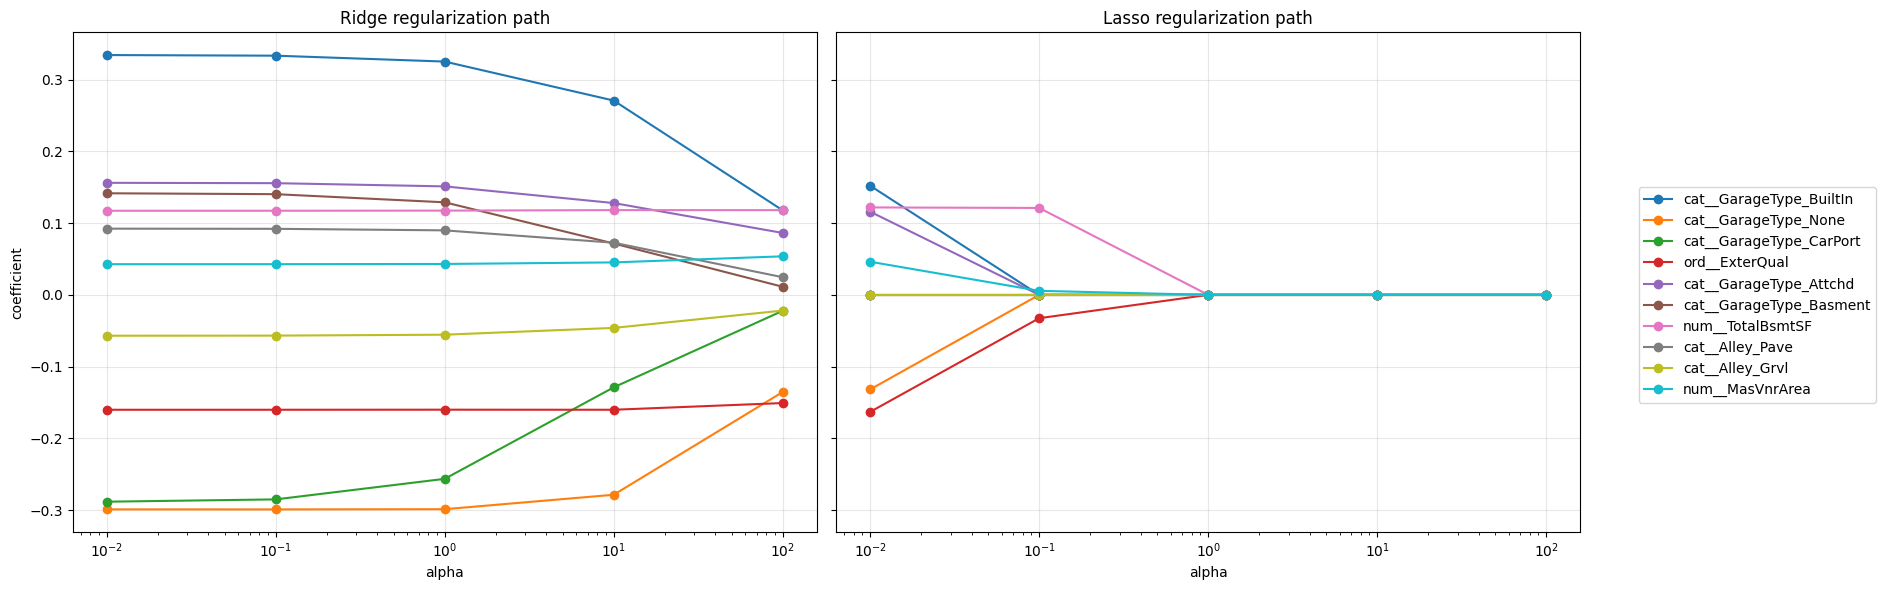

In [12]:
preprocessor = joblib.load(PREPROCESSOR_PATH)
feature_names = preprocessor.get_feature_names_out()

linear_abs_coef = np.abs(linear_model.coef_)
top_feature_count = min(10, len(feature_names))
top_feature_idx = np.argsort(linear_abs_coef)[-top_feature_count:][::-1]
top_feature_names = feature_names[top_feature_idx]

ridge_path = pd.DataFrame(
    [ridge_models[alpha].coef_[top_feature_idx] for alpha in alphas],
    index=alphas,
    columns=top_feature_names,
)
lasso_path = pd.DataFrame(
    [lasso_models[alpha].coef_[top_feature_idx] for alpha in alphas],
    index=alphas,
    columns=top_feature_names,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for feature in ridge_path.columns:
    axes[0].plot(ridge_path.index, ridge_path[feature], marker="o", label=feature)
axes[0].set_xscale("log")
axes[0].set_title("Ridge regularization path")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("coefficient")
axes[0].grid(True, alpha=0.3)

for feature in lasso_path.columns:
    axes[1].plot(lasso_path.index, lasso_path[feature], marker="o", label=feature)
axes[1].set_xscale("log")
axes[1].set_title("Lasso regularization path")
axes[1].set_xlabel("alpha")
axes[1].grid(True, alpha=0.3)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.18, 0.5))
fig.tight_layout()
plt.show()

## 13. Lasso Feature Selection

Lasso can set coefficients to zero. A zero coefficient means the model is not using that transformed feature at that alpha.

In [13]:
lasso_zero_rows = []

for alpha in alphas:
    zero_features = feature_names[np.isclose(lasso_models[alpha].coef_, 0.0, atol=1e-8)]
    lasso_zero_rows.append(
        {
            "alpha": alpha,
            "zero_coefficients": len(zero_features),
            "zero_features": ", ".join(zero_features) if len(zero_features) else "None",
        }
    )

lasso_zero_features = pd.DataFrame(lasso_zero_rows)
display(lasso_zero_features)

,alpha,zero_coefficients,zero_features
0,0.01,7,"cat__GarageType_2Types, cat__GarageType_Basmen..."
1,0.10,11,"num__LotFrontage, cat__GarageType_2Types, cat_..."
2,1.00,14,"num__LotFrontage, num__MasVnrArea, num__TotalB..."
3,10.00,14,"num__LotFrontage, num__MasVnrArea, num__TotalB..."
4,100.00,14,"num__LotFrontage, num__MasVnrArea, num__TotalB..."


## 14. Final Model Comparison

In [14]:
selected_ridge = Ridge(alpha=best_ridge_alpha)
selected_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)

final_comparison = pd.DataFrame(
    [
        dummy_metrics,
        linear_metrics,
        evaluate_model(selected_ridge, f"Ridge(alpha={best_ridge_alpha})"),
        evaluate_model(selected_lasso, f"Lasso(alpha={best_lasso_alpha})"),
    ]
)

display(final_comparison)

,model,rmse_log,mae_log,r2
0,DummyRegressor(mean),0.433244,0.337134,-0.005837
1,LinearRegression,0.247841,0.176736,0.670840
2,Ridge(alpha=10.0),0.246174,0.175697,0.675251
3,Lasso(alpha=0.01),0.254712,0.184779,0.652335


## Session Summary

- Reused the exact Session 1 feature set, preprocessing, log target, and train/test split.
- Compared Dummy, Linear Regression, Ridge, and Lasso on RMSE/MAE/R2.
- Swept alpha values to see how stronger regularization changes metrics and coefficients.
- Visualized Ridge and Lasso regularization paths.
- Checked how many coefficients Lasso sets to zero at each alpha.